# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Apple App Store Dataset](https://www.kaggle.com/datasets/ashyou09/apple-app-store-dataset-2026-edition)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('apple_appstore_2026.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,App_ID,App_Name,Developer,Primary_Genre,Genres,User_Rating,Rating_Count,Price_USD,Type,Size_Bytes,Content_Rating,Last_Updated,Current_Version,Min_iOS_Version,In_App_Purchases,Supported_Devices
0,1616910453,Tracker,Meta Maker Ltd.,Games,"Games, Puzzle",5.0,3816498,0.00,Free,1281242501,12+,2026-02-18,7.34,17.0,No,"iPhone, iPad, iPod touch"
1,1016144585,Pay Online,Epic Health Ltd.,Social Networking,Social Networking,4.6,3654718,4.99,Paid,177934219,17+,2024-12-09,13.3,18.0,No,"Mac, iPhone, iPad"
2,1530831403,Maker Online,Smart Fit Ltd.,Weather,Weather,5.0,3604458,0.00,Free,109751867,4+,2024-12-24,20.28,16.0,Yes,iPhone only
3,1621267440,Connect 2023,Easy Studio Ltd.,Productivity,Productivity,4.4,3593687,0.00,Free,101875436,4+,2025-05-24,12.6.33,17.0,Yes,"iPhone, iPad, iPod touch"
4,1416005364,Quick Editor,i Connect Ltd.,Games,"Games, Simulation",4.3,3559409,0.00,Free,1744557391,9+,2024-02-10,16.47,13.0,Yes,iPhone only


## last Five row

In [4]:
df.tail()

,App_ID,App_Name,Developer,Primary_Genre,Genres,User_Rating,Rating_Count,Price_USD,Type,Size_Bytes,Content_Rating,Last_Updated,Current_Version,Min_iOS_Version,In_App_Purchases,Supported_Devices
11495,1469548728,Chat,Super Connect Ltd.,Social Networking,Social Networking,NaN,0,0.0,Free,128156287,17+,2024-07-02,4.49,12.0,No,"iPhone, iPad, iPod touch"
11496,1816058987,Planner Online,Hyper Planner Ltd.,Photo & Video,"Photo & Video, Utilities",NaN,0,0.0,Free,293157200,4+,2022-01-04,15.20,17.0,Yes,"iPhone, iPad, iPod touch"
11497,893047688,Zen Pay,Ultra Browser Ltd.,Health & Fitness,Health & Fitness,NaN,0,0.0,Free,17576929,12+,2025-08-07,9.22,15.0,Yes,iPhone only
11498,1724012767,Fit Space,Super Scanner Ltd.,Games,"Games, Casual",NaN,0,0.0,Free,867345396,4+,2023-10-20,8.49,15.0,Yes,"Mac, iPhone, iPad"
11499,512377783,Player Premium,i Maker Ltd.,Health & Fitness,Health & Fitness,NaN,0,0.0,Free,36279189,17+,2023-02-25,12.17,16.0,No,"iPhone, iPad, iPod touch"


## Shape of our dataset

In [5]:
df.shape

(11500, 16)

## List out all columns

In [6]:
df.columns

Index(['App_ID', 'App_Name', 'Developer', 'Primary_Genre', 'Genres',
       'User_Rating', 'Rating_Count', 'Price_USD', 'Type', 'Size_Bytes',
       'Content_Rating', 'Last_Updated', 'Current_Version', 'Min_iOS_Version',
       'In_App_Purchases', 'Supported_Devices'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

App_ID                 int64
App_Name              object
Developer             object
Primary_Genre         object
Genres                object
User_Rating          float64
Rating_Count           int64
Price_USD            float64
Type                  object
Size_Bytes             int64
Content_Rating        object
Last_Updated          object
Current_Version       object
Min_iOS_Version      float64
In_App_Purchases      object
Supported_Devices     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   App_ID             11500 non-null  int64  
 1   App_Name           11500 non-null  object 
 2   Developer          11500 non-null  object 
 3   Primary_Genre      11500 non-null  object 
 4   Genres             11500 non-null  object 
 5   User_Rating        11346 non-null  float64
 6   Rating_Count       11500 non-null  int64  
 7   Price_USD          11500 non-null  float64
 8   Type               11500 non-null  object 
 9   Size_Bytes         11500 non-null  int64  
 10  Content_Rating     11500 non-null  object 
 11  Last_Updated       11500 non-null  object 
 12  Current_Version    11500 non-null  object 
 13  Min_iOS_Version    11500 non-null  float64
 14  In_App_Purchases   11500 non-null  object 
 15  Supported_Devices  11500 non-null  object 
dtypes: float64(3), int64(3

## Check Null Value

In [9]:
df.isnull().sum()

App_ID                 0
App_Name               0
Developer              0
Primary_Genre          0
Genres                 0
User_Rating          154
Rating_Count           0
Price_USD              0
Type                   0
Size_Bytes             0
Content_Rating         0
Last_Updated           0
Current_Version        0
Min_iOS_Version        0
In_App_Purchases       0
Supported_Devices      0
dtype: int64

## Drop Null Features

In [10]:
df.drop(columns=['User_Rating'], inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,App_ID,Rating_Count,Price_USD,Size_Bytes,Min_iOS_Version
count,1.150000e+04,1.150000e+04,11500.000000,1.150000e+04,11500.000000
mean,1.149057e+09,3.559272e+05,0.397268,4.862294e+08,16.133130
std,4.957809e+08,5.304634e+05,9.590691,7.420646e+08,1.294431
min,2.842020e+08,0.000000e+00,0.000000,1.574220e+07,12.000000
25%,7.200681e+08,2.696000e+03,0.000000,9.627423e+07,15.000000
50%,1.155344e+09,1.168425e+05,0.000000,1.689742e+08,16.000000
75%,1.574683e+09,4.937378e+05,0.000000,4.132639e+08,17.000000
max,1.999987e+09,3.816498e+06,999.990000,3.142902e+09,18.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

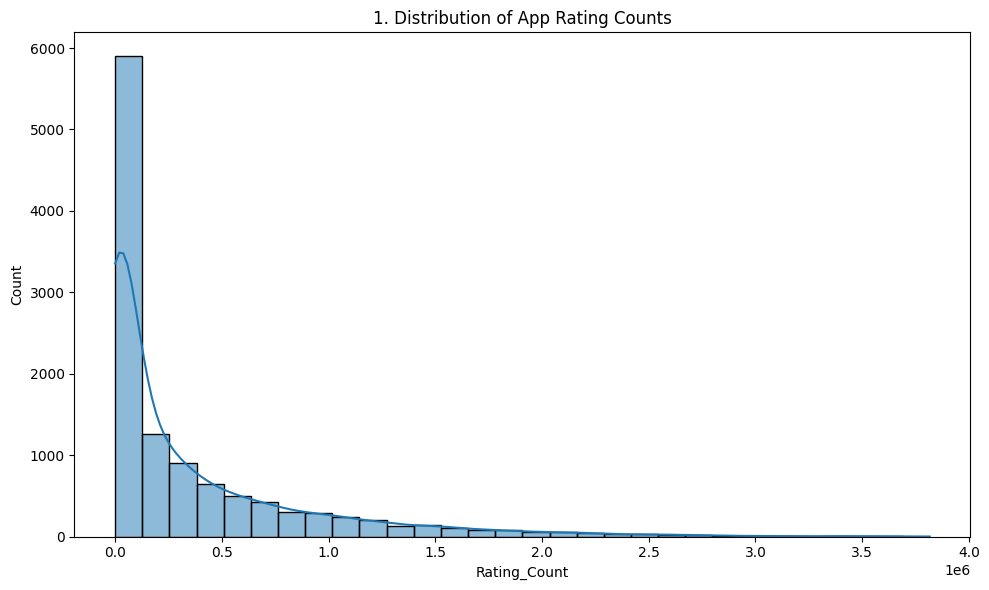

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Rating_Count'], bins=30, kde=True)
plt.title(f'{plot_no}. Distribution of App Rating Counts')
show_fig()
plot_no += 1

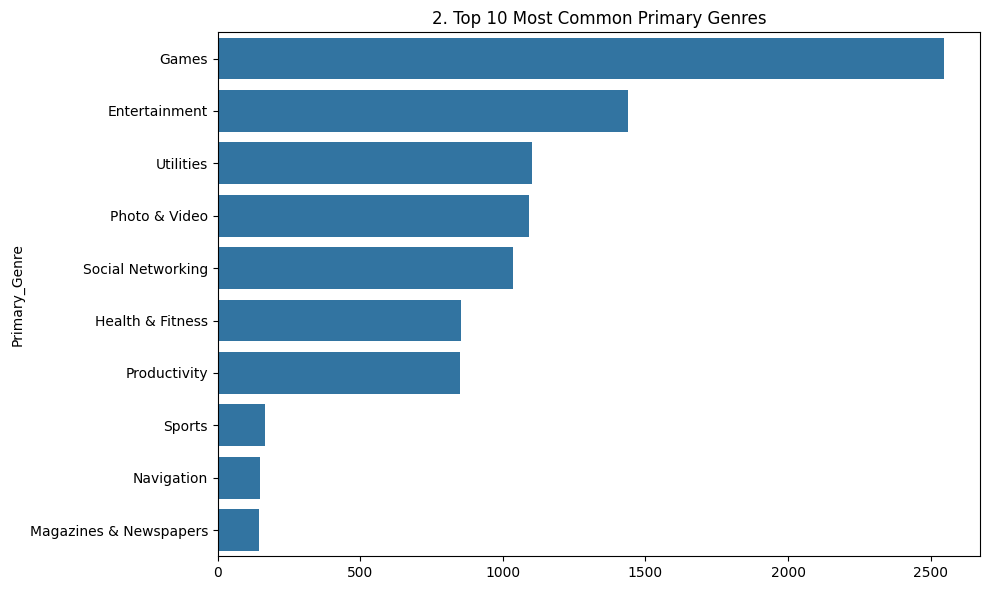

In [15]:
fig = plt.figure(figsize=(10,6))
top_genres = df['Primary_Genre'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title(f'{plot_no}. Top 10 Most Common Primary Genres')
show_fig()
plot_no += 1

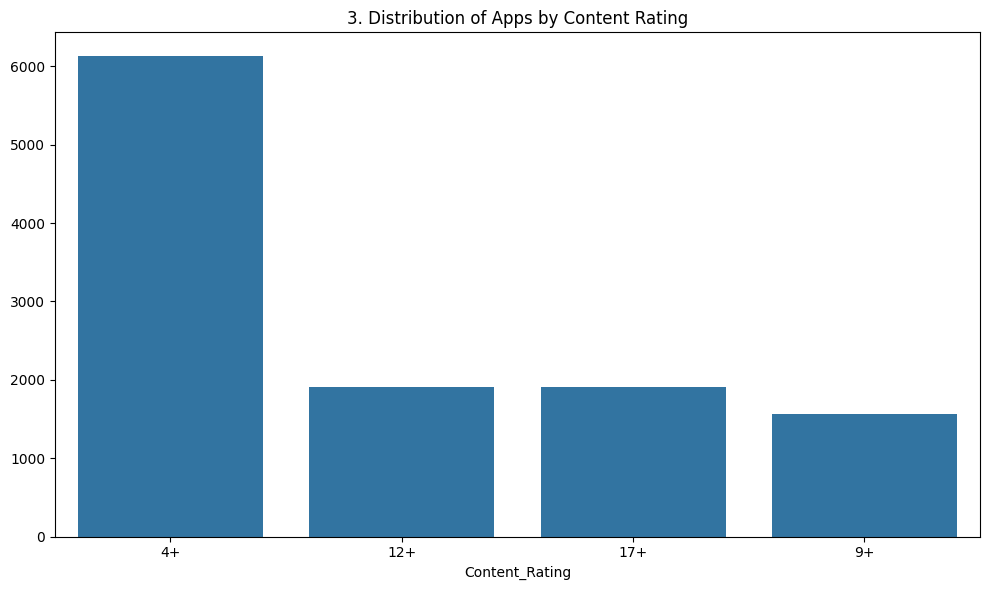

In [16]:
fig = plt.figure(figsize=(10,6))
top_content = df['Content_Rating'].value_counts()
sns.barplot(x=top_content.index, y=top_content.values)
plt.title(f'{plot_no}. Distribution of Apps by Content Rating')
show_fig()
plot_no += 1

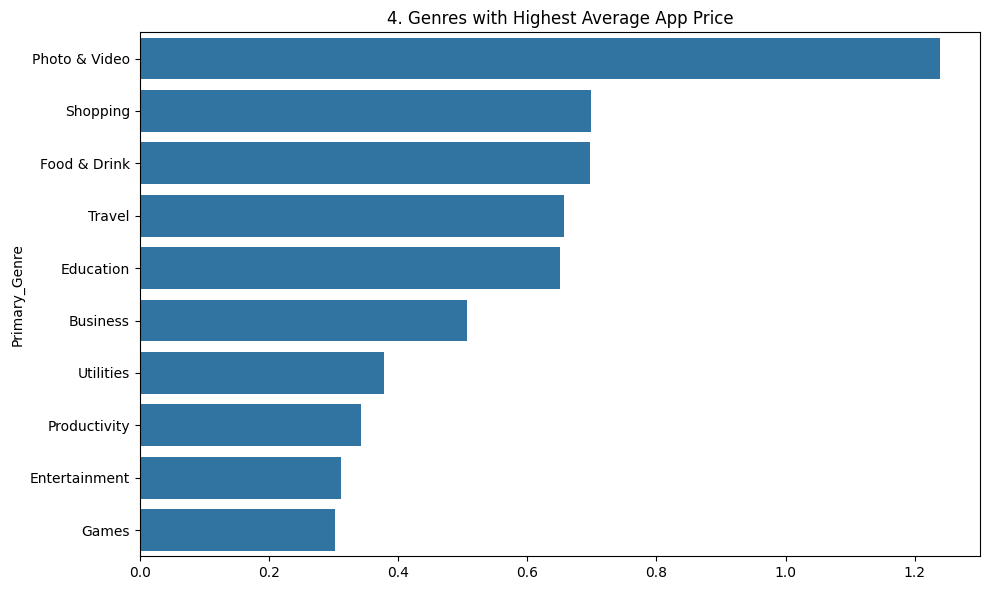

In [17]:
fig = plt.figure(figsize=(10,6))
top_paid = df.groupby('Primary_Genre')['Price_USD'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_paid.values, y=top_paid.index)
plt.title(f'{plot_no}. Genres with Highest Average App Price')
show_fig()
plot_no += 1

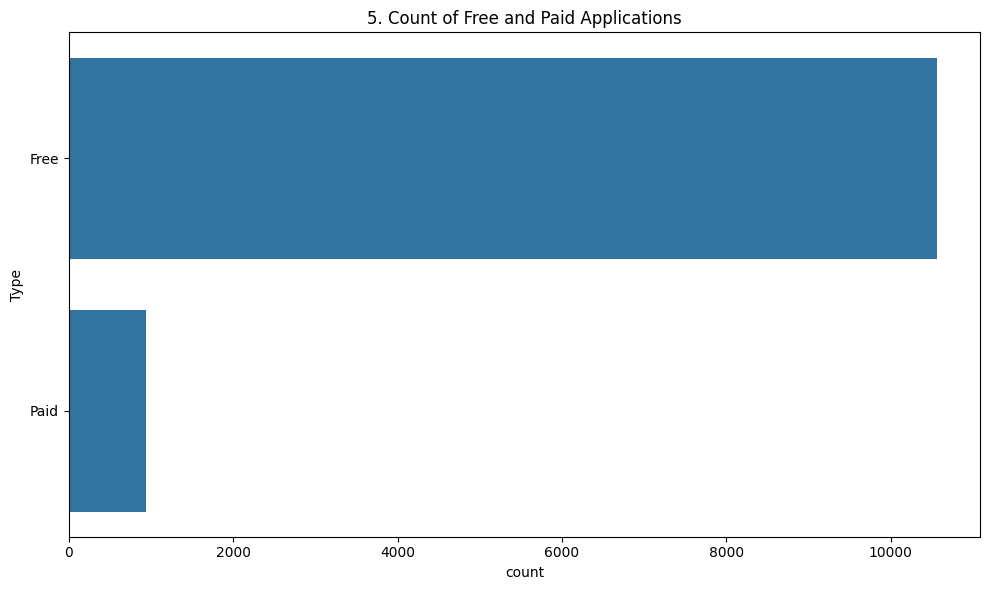

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(y='Type', data=df)
plt.title(f'{plot_no}. Count of Free and Paid Applications')
show_fig()
plot_no += 1

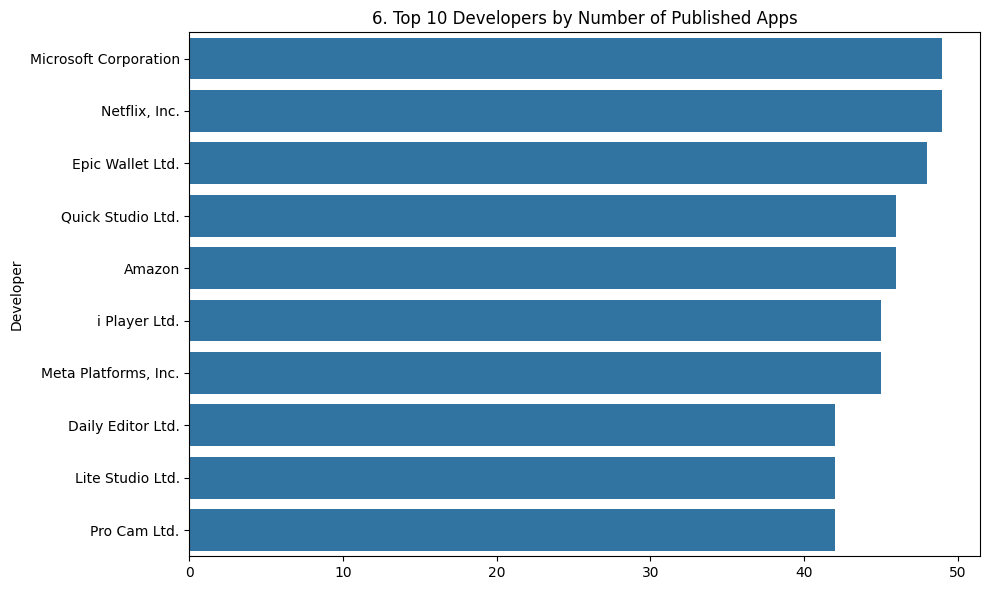

In [19]:
fig = plt.figure(figsize=(10,6))
top_developers = df['Developer'].value_counts().head(10)
sns.barplot(x=top_developers.values, y=top_developers.index)
plt.title(f'{plot_no}. Top 10 Developers by Number of Published Apps')
show_fig()
plot_no += 1

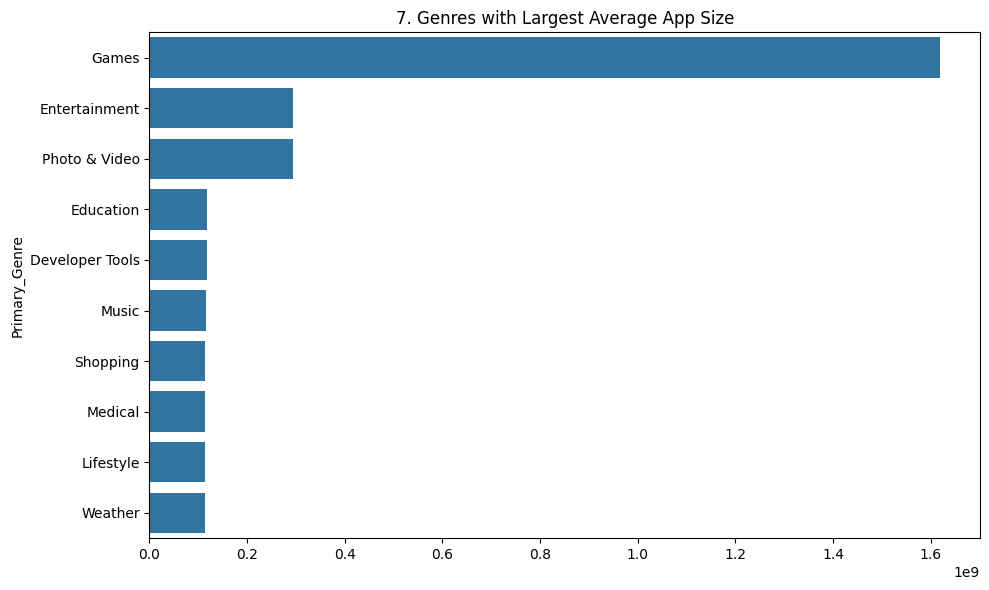

In [20]:
fig = plt.figure(figsize=(10,6))
top_size = df.groupby('Primary_Genre')['Size_Bytes'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_size.values, y=top_size.index)
plt.title(f'{plot_no}. Genres with Largest Average App Size')
show_fig()
plot_no += 1

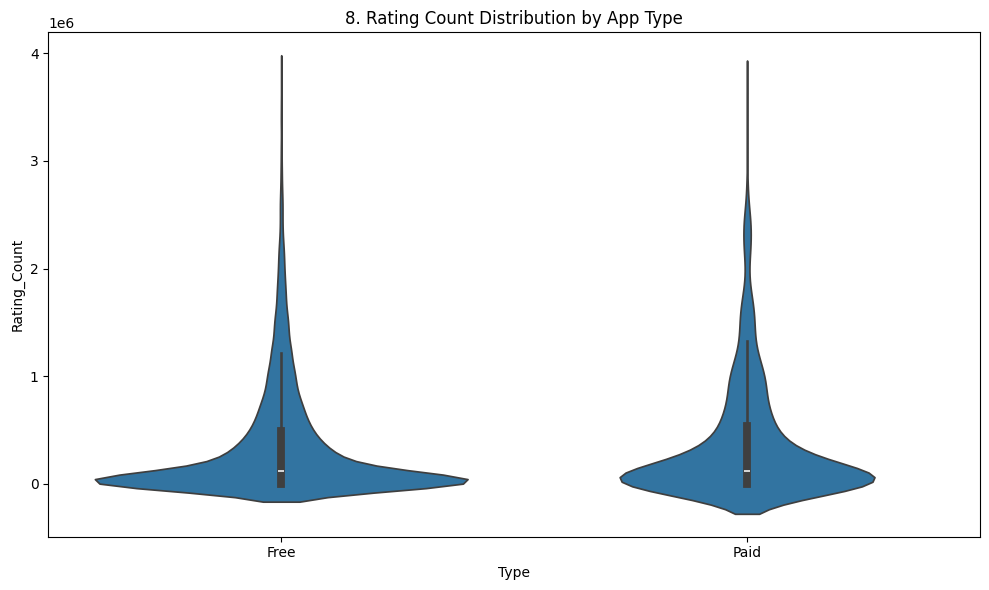

In [21]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Type', y='Rating_Count', data=df)
plt.title(f'{plot_no}. Rating Count Distribution by App Type')
show_fig()
plot_no += 1

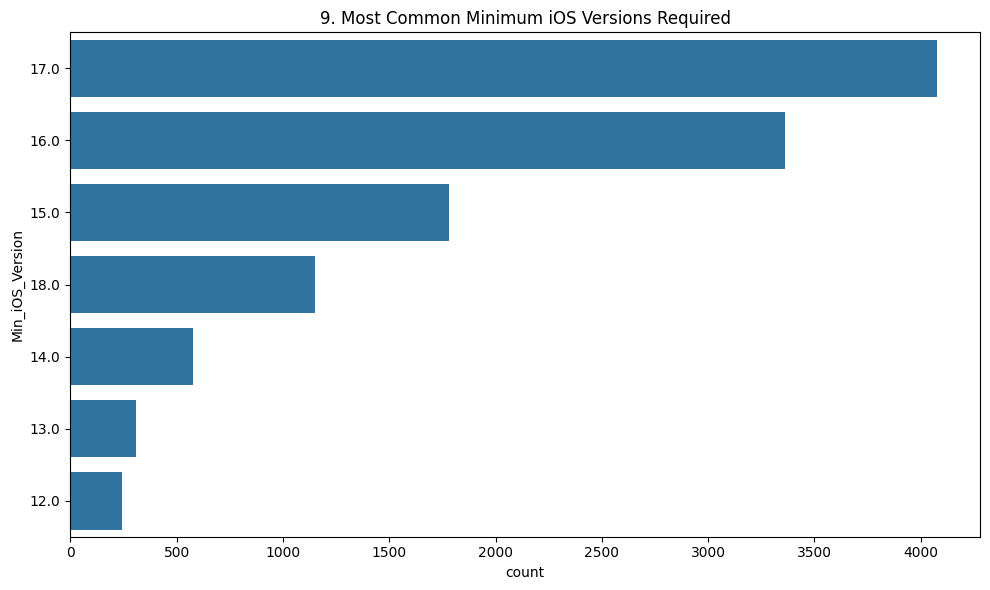

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(y='Min_iOS_Version', data=df, order=df['Min_iOS_Version'].value_counts().head(10).index)
plt.title(f'{plot_no}. Most Common Minimum iOS Versions Required')
show_fig()
plot_no += 1

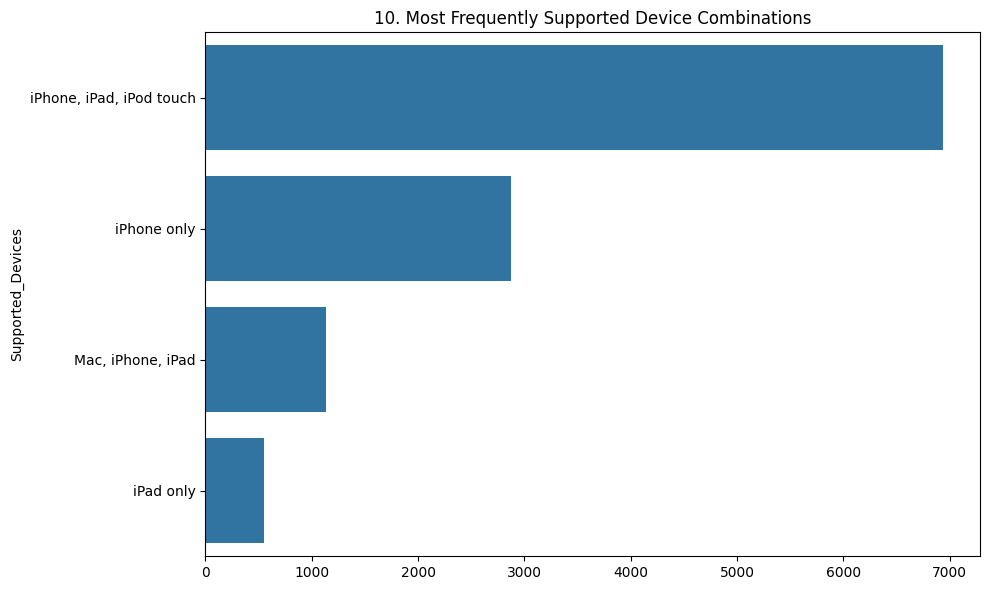

In [23]:
fig = plt.figure(figsize=(10,6))
top_devices = df['Supported_Devices'].value_counts().head(10)
sns.barplot(x=top_devices.values, y=top_devices.index)
plt.title(f'{plot_no}. Most Frequently Supported Device Combinations')
show_fig()
plot_no += 1

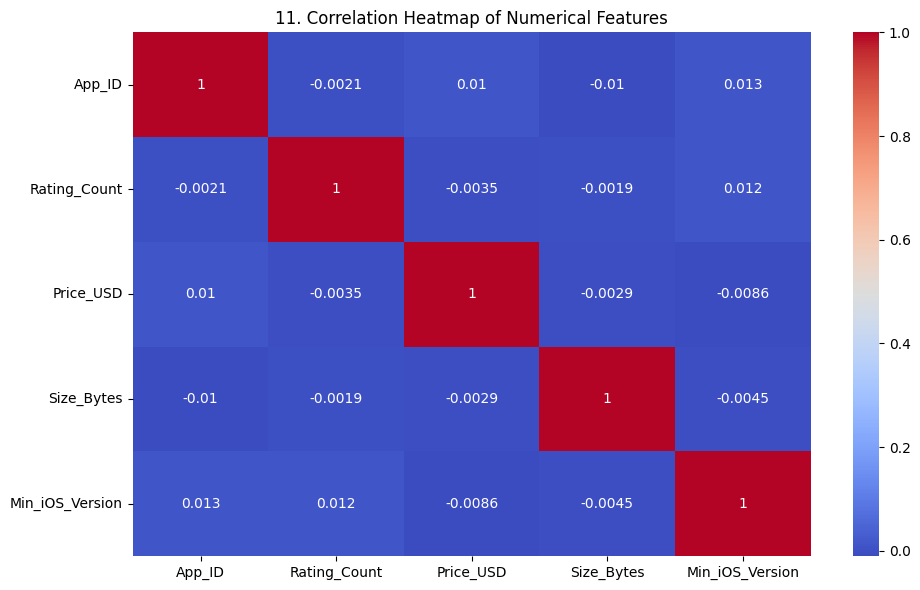

In [24]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## Create Copy of Dataset

In [25]:
data = df.copy()

## Select Target Column

In [26]:
target = "Type"

## Remove Missing Target Values

In [27]:
data = data.dropna(subset=[target])

## Separate Features and Target

In [28]:
X = data.drop(columns=[target])
y = data[target]

## Encode Target Labels

In [29]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

## Identify Numeric and Categorical Columns

In [30]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

## Create Numeric Preprocessing Pipeline

In [31]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## Create Categorical Preprocessing Pipeline

In [32]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", __import__("sklearn").preprocessing.OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

## Combine Preprocessing

In [33]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Split Dataset

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create SVM Classification Model

In [35]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(kernel="rbf", random_state=42))
])

## Train Model

In [36]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict Test Data

In [37]:
y_pred = model.predict(X_test)

## Print Accuracy

In [38]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score :", round(accuracy * 100, 2), "%")

Accuracy Score : 91.83 %


## Print Classification Report

In [39]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))


Classification Report:

              precision    recall  f1-score   support

        Free       0.92      1.00      0.96      2112
        Paid       0.00      0.00      0.00       188

    accuracy                           0.92      2300
   macro avg       0.46      0.50      0.48      2300
weighted avg       0.84      0.92      0.88      2300



## Plot Confusion Matrix

<Figure size 800x600 with 0 Axes>

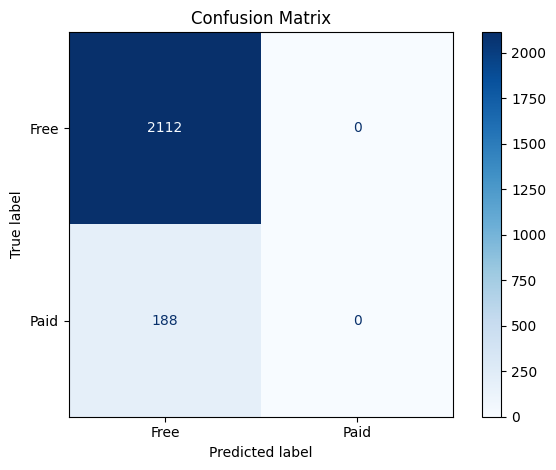

In [40]:
plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_encoder.classes_,
    cmap="Blues",
    values_format="d"
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()